<a href="https://colab.research.google.com/github/d-toups/workout-data-analysis/blob/main/workout_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workout Data Analysis: Gender & Age Differences in Fitness Preferences & Calorie Burn

**Objective**:  
Explore how workout preferences and calorie expenditure differ by gender and age group using exploratory data analysis.

**Business Value**:  
These insights can help fitness apps, gyms, and wellness platforms create more targeted programs and recommendations.

## 1. Project Overview

## Project Goal
Analyze workout preferences and calorie expenditure patterns across different genders and age groups using exploratory data analysis.

**Business Context**:  
Understanding demographic differences in fitness behavior can help gyms, fitness apps, and health companies create more personalized programs and marketing strategies.

## Key Questions
- What workout types are most popular among different genders?
- How does calorie burn vary by age group and workout type?
- Are there noticeable differences in behavior between males and females?

## Tech Stack
- Python (pandas, seaborn, matplotlib)
- Jupyter Notebook

## 2. Imports and Setup

In [1]:
# Import functions
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.data_loader import (
    load_dataset,
    clean_dataset
)
from src.feature_engineering import engineer_features

from src.eda import (
    plot_workout_by_age_group,
    plot_cpm,
    stats,
    find_correlations
)
from src.feature_selection import (
    feature_importance,
    run_random_forest,
    run_xgboost,
    run_knn,
    select_models_features,
    print_models
)
from src.modeling import tune_and_evaluate, final_evaluation

## 3. Data Loading and Cleaning

In [2]:
# Load and Clean the Dataset
df_raw = load_dataset("gym_members_exercise_tracking.csv")
df_clean = clean_dataset(df_raw)

print(f"Dataset shape after cleaning: {df_clean.shape}")

Dataset shape after cleaning: (973, 9)


### Cleaning actions include:
- Remove samples with NAN values
- Filter out ambiguous "Other" entries for gender
- Transform Session Duration from hours to minutes
- Remove any numerical samples with non-numerical entries
- Confirm data cleaning by checking unique values of gender and workout type
- Notably, the dataset contained no records for individuals over age 59. Thus, a Seniors cohort could not be analyzed

## 4. Feature Engineering

In [3]:
# Engineer Features
df = engineer_features(df_clean)

### Key engineered features included:
- Calories Per Minute (intensity metric)
- Age Group and Body Fat Group (binned categorical variables)
- Encoded versions of categorical columns for modeling

## 5. Key Visualizations

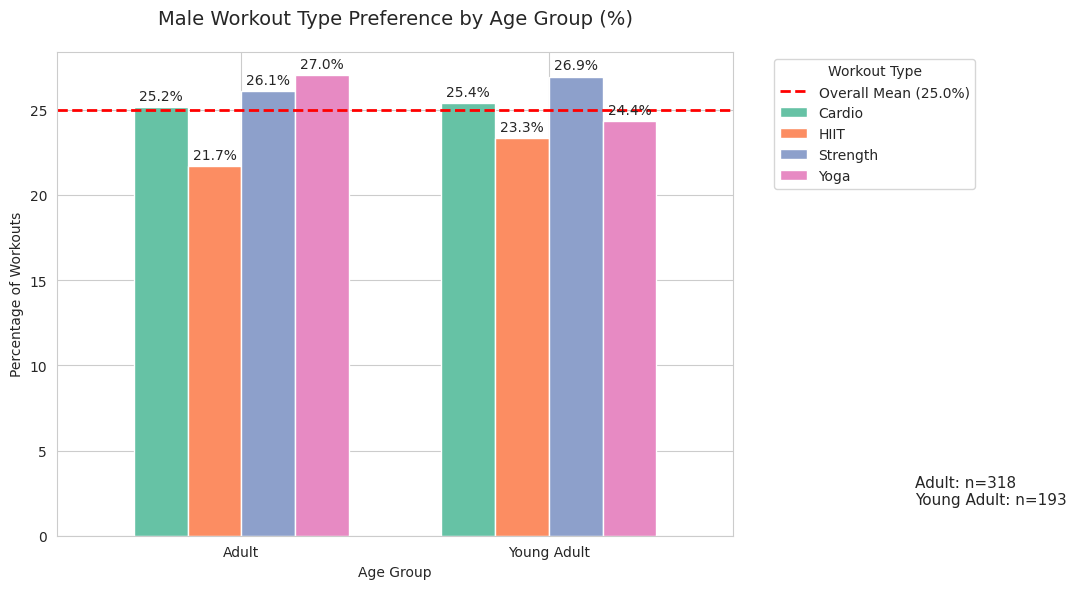

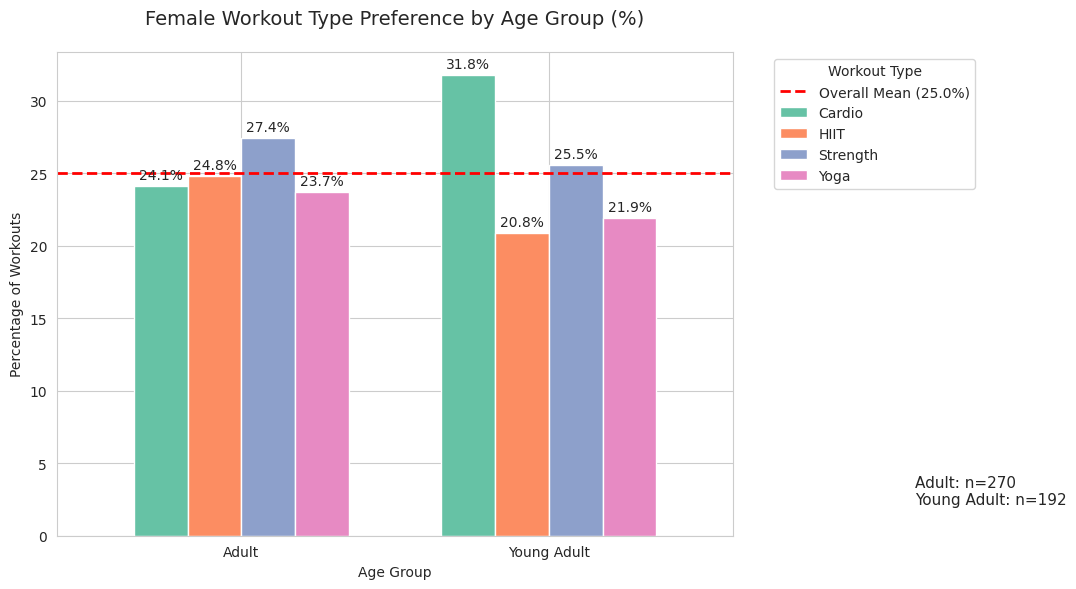

In [4]:
# 1. Plot Workout Preference by Age Group (Males)
plot_workout_by_age_group(df)

**Male Workout Type Preferences by Age Group**
- Adult males showed a relatively high preference for **Yoga** compared to other groups. This may reflect selection bias in the dataset (e.g., the source gym/app may attract men interested in mobility and recovery training) or genuine shifts toward lower-impact activities in this age group.
- Young Adults show a small preference for **Strength Training** as well as **Cardio**.
- The largest difference in preference between adult and young adult men is adults' 2.6% favorability of **Yoga**.
- Both groups favor **HIIT** least.

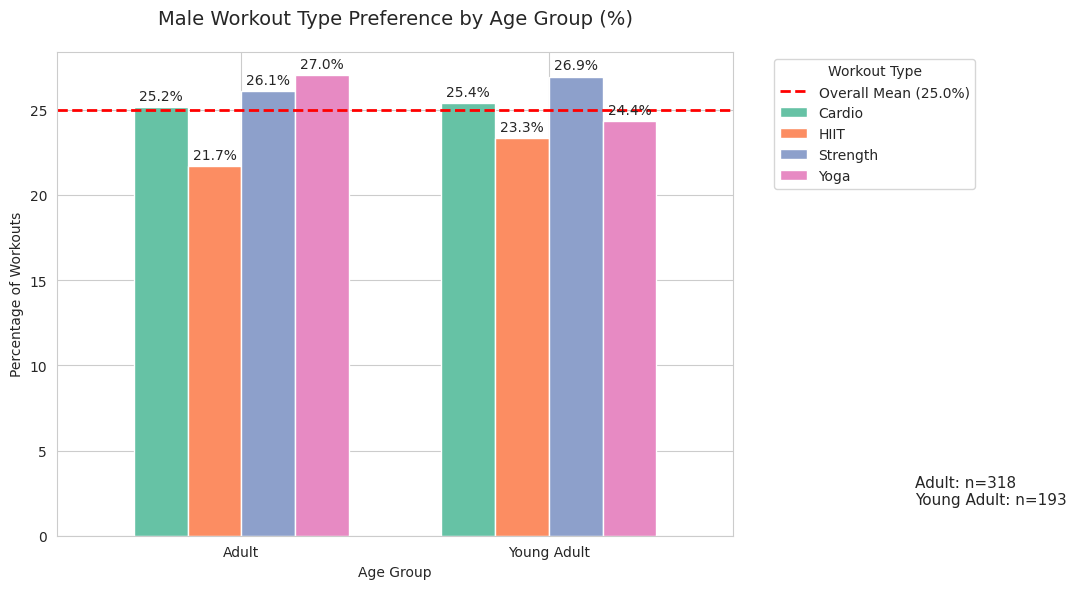

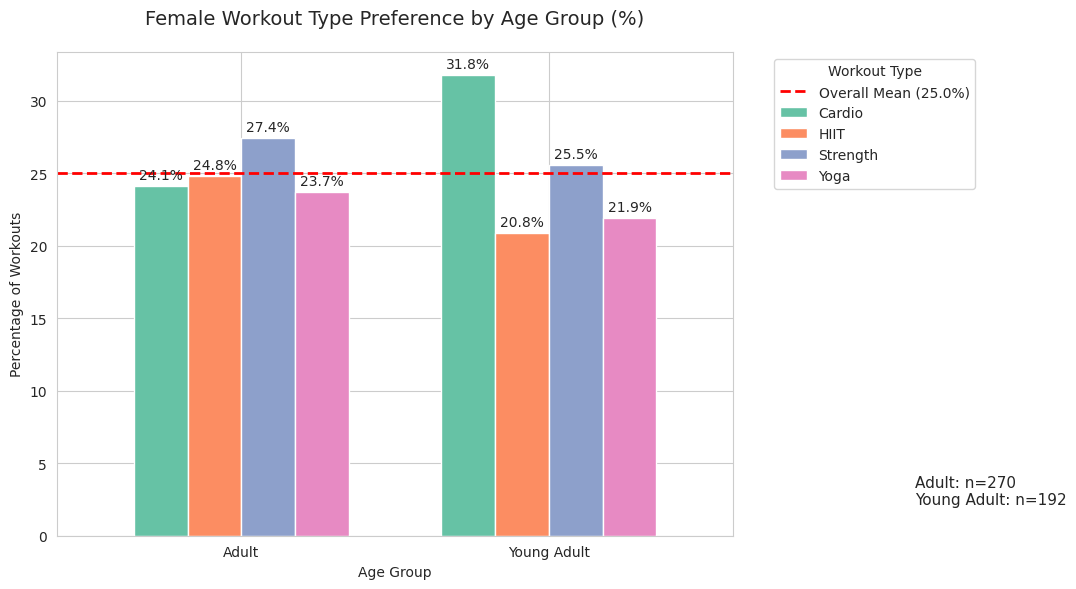

In [5]:
# 2. Plot Workout Preference by Age Group (Females)
plot_workout_by_age_group(df)

**Female Workout Type Preferences by Age Group**
- Adult females most strongly favor **Strength Training**.
- Young adult females prefer **Cardio** 6.3% above mean.
- Adult females least favor **Yoga**, while young adults prefer **HIIT** least.
- The largest difference between these groups is young adult females' 7.7% favorability of **Cardio** compared to adults.

**Overall Preference Insights**
- Both males and females consistently favor **Strength Training** and **Cardio** across both age groups, though adult men in this dataset most prefer **Yoga**.
- The difference in workout preferences between genders is visible in both age groups, though the magnitude varies.

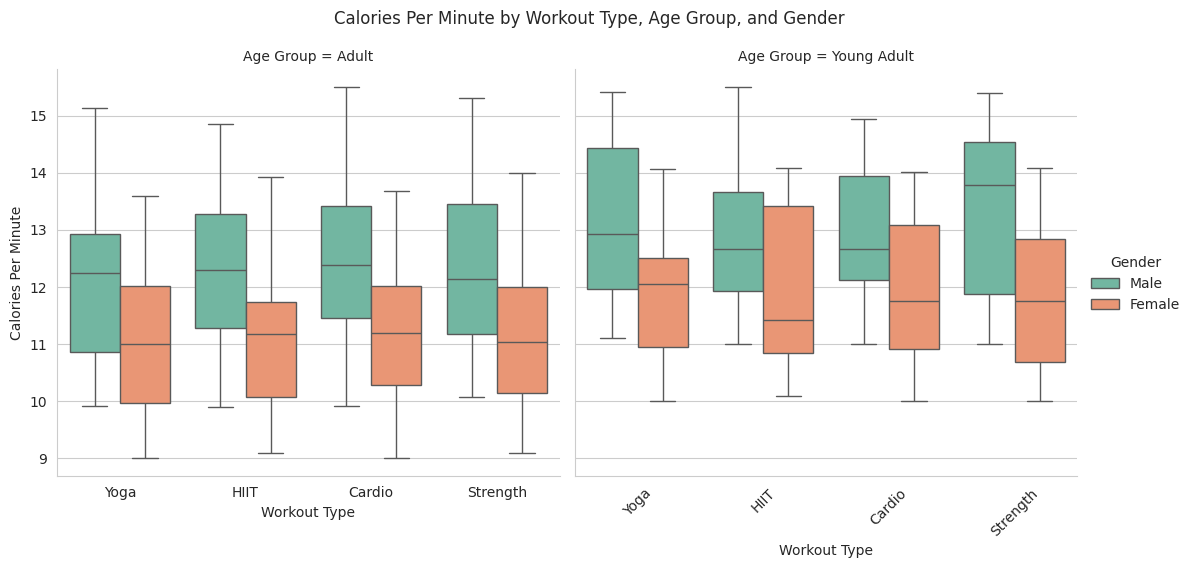

In [6]:
# 3. Plot Calories per Minute by Workout Type and Gender
plot_cpm(df)

**Intensity (Calories Per Minute)**
- **Young Adults** consistently perform higher intensity exercise in every category (as expected).
- **Young Adult males** tend to achieve the highest peak calorie burn rates, especially during Strength Training and Yoga.
- Females generally show more consistent (less variable) calorie burn across workout types compared to males, with exception of young adult female **HIIT** participants, who saw several high outliers.
- **Strength Training** exhibits the highest variability in intensity among males.

## 6. Statistical Analysis

In [7]:
## Conduct chi-square and t-testing on dataset
stats(df)


--------- Chi square tests  ---------

Age Group: Adult (588 samples)
   Chi-square p-value: 0.7021 → Not significant
   Contingency Table:
Workout Type  Cardio  HIIT  Strength  Yoga
Gender                                    
Female            65    67        74    64
Male              80    69        83    86
Age Group: Young Adult (385 samples)
   Chi-square p-value: 0.5785 → Not significant
   Contingency Table:
Workout Type  Cardio  HIIT  Strength  Yoga
Gender                                    
Female            61    40        49    42
Male              49    45        52    47

--------- T-tests by age group within each gender ---------

Male | Age (511 total samples)
   Young Adult : n=193, Mean = 25.82
   Adult       : n=318, Mean = 46.99
   p-value     : 0.0000 → Significant difference

Male | Avg Bpm (511 total samples)
   Young Adult : n=193, Mean = 142.57
   Adult       : n=318, Mean = 144.70
   p-value     : 0.1031 → No significant difference

Male | Calories Burned (511

### Analysis

Statistical tests were conducted to validate visual observations:

- **Chi-square Test of Independence**: No significant association between gender and workout type preference (p = 0.7021 for adults, p = 0.5785 for young adults).
- **Independent T-Tests on Calories Per Minute**:
  - Young Adult vs Adult Males: p < 0.001
  - Young Adult vs Adult Females: p < 0.001

**Key Finding**: **Age group is a strong predictor of training intensity**, while **gender has no statistically significant predictive power** for either workout type preference or training intensity.

## 7. Correlation

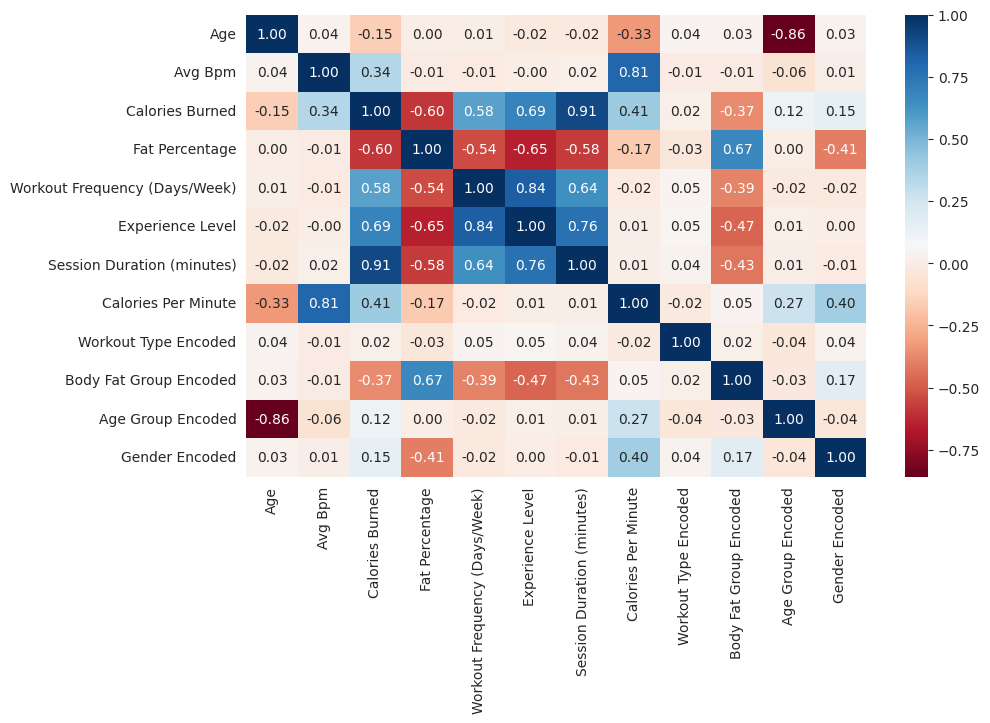

In [8]:
## Look for correlations among features
find_correlations(df)

## Correlation Analysis

A correlation heatmap was generated to explore relationships between numerical features.

### Key Observations:
- **Calories Per Minute** shows moderate positive correlation with **Average BPM** and **Session Duration**, as expected — these metrics collectively represent training intensity.
- **CPM** moderate negative correlation with **Age** matches statistical findings (young adults train at higher intensity than adults)
- **Fat Percentage** shows moderate negative correlation with **Calories Burned**, **Workout Frequency**, **Experience Level**, and **Session Duration**. This suggests that individuals with lower body fat percentages tend to train more frequently, for longer durations, and at higher experience levels.
- Interestingly, **body fat percentage** shows only a weak negative correlation with training intensity. This suggests that individuals with higher body fat percentages still train at comparable intensity levels on average, indicating that intensity is not strongly determined by body composition in this dataset.
- **Age** has a noticeable negative correlation with training intensity metrics (Calories Per Minute, Average BPM). This supports the earlier finding that younger individuals tend to train at higher intensity.
- **Workout Frequency**, **Experience Level**, and **Session Duration** show moderate positive correlations with each other, indicating that more experienced individuals tend to train more frequently and for longer sessions.

**Insight**: The strongest relationships in the data revolve around **training intensity and experience-related behaviors**. Demographic factors (like Age and Fat Percentage) play a supporting role, but behavioral and physiological effort metrics appear to be the primary drivers.

## 8. Feature Selection and Importance

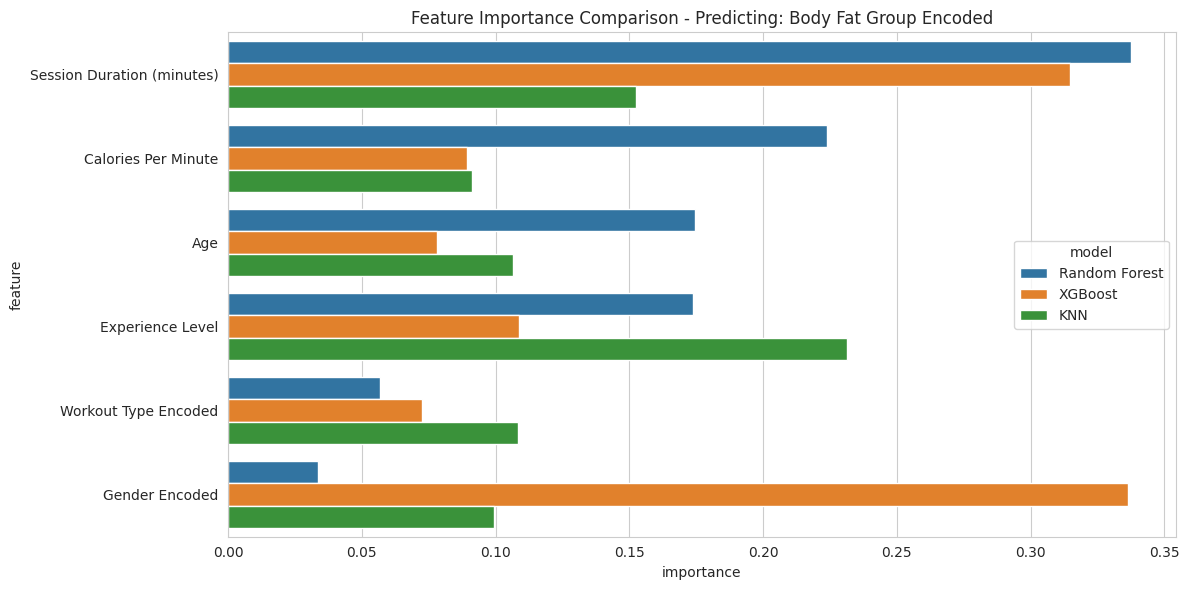


Top 5 features for predicting 'Body Fat Group Encoded':
Random Forest:
                      feature  importance
2  Session Duration (minutes)    0.337335
5         Calories Per Minute    0.223723
0                         Age    0.174521
4            Experience Level    0.173853
3        Workout Type Encoded    0.056870

XGBoost:
                      feature  importance
1              Gender Encoded    0.336549
2  Session Duration (minutes)    0.314599
4            Experience Level    0.108749
5         Calories Per Minute    0.089406
0                         Age    0.078092
\K Nearest Neighbors:
                      feature  importance
4            Experience Level    0.231244
2  Session Duration (minutes)    0.152518
3        Workout Type Encoded    0.108222
0                         Age    0.106680
1              Gender Encoded    0.099486


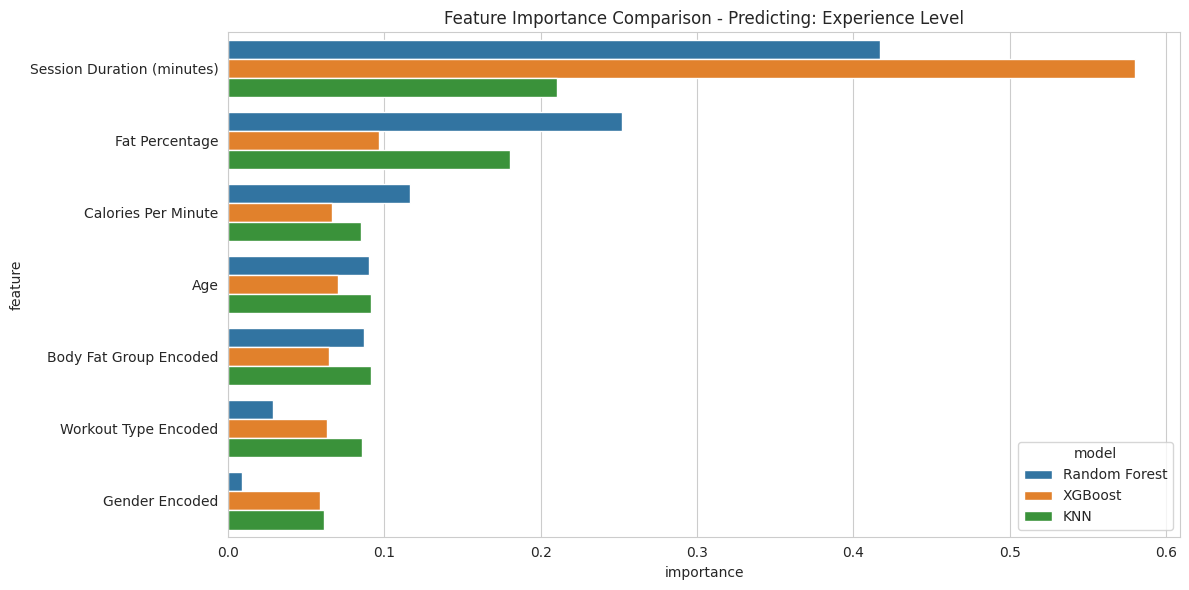


Top 5 features for predicting 'Experience Level':
Random Forest:
                      feature  importance
2  Session Duration (minutes)    0.416946
4              Fat Percentage    0.252170
6         Calories Per Minute    0.116639
0                         Age    0.090272
5      Body Fat Group Encoded    0.086688

XGBoost:
                      feature  importance
2  Session Duration (minutes)    0.579954
4              Fat Percentage    0.096359
0                         Age    0.070416
6         Calories Per Minute    0.066236
5      Body Fat Group Encoded    0.064368
\K Nearest Neighbors:
                      feature  importance
2  Session Duration (minutes)    0.210483
4              Fat Percentage    0.180576
0                         Age    0.091470
5      Body Fat Group Encoded    0.091161
3        Workout Type Encoded    0.085817


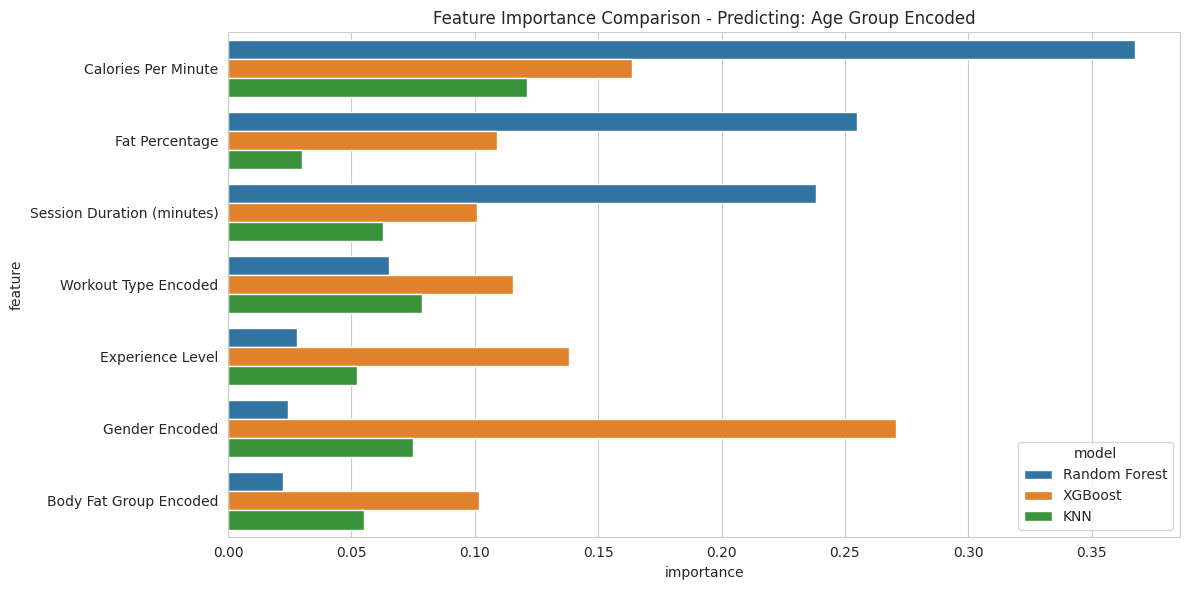


Top 5 features for predicting 'Age Group Encoded':
Random Forest:
                      feature  importance
6         Calories Per Minute    0.367414
3              Fat Percentage    0.254821
1  Session Duration (minutes)    0.238161
2        Workout Type Encoded    0.065197
4            Experience Level    0.027815

XGBoost:
                feature  importance
0        Gender Encoded    0.270863
6   Calories Per Minute    0.163772
4      Experience Level    0.138093
2  Workout Type Encoded    0.115614
3        Fat Percentage    0.109040
\K Nearest Neighbors:
                      feature  importance
6         Calories Per Minute    0.121069
2        Workout Type Encoded    0.078417
0              Gender Encoded    0.074820
1  Session Duration (minutes)    0.063001
5      Body Fat Group Encoded    0.055087


In [9]:
## Feature Importance
rf_top_features_dict, xgb_top_features_dict, knn_top_features_dict = feature_importance(df)
rf_result = xgb_result = knn_result = {}

## Feature Assessment and Selection

RF Body Fat Group Encoded CV Accuracy: 0.5835 ± 0.0206

Body Fat Group Encoded Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        31
           1       0.48      0.29      0.36        75
           2       0.00      0.00      0.00         7
           3       0.52      0.71      0.60        82

    accuracy                           0.55       195
   macro avg       0.45      0.48      0.45       195
weighted avg       0.53      0.55      0.53       195



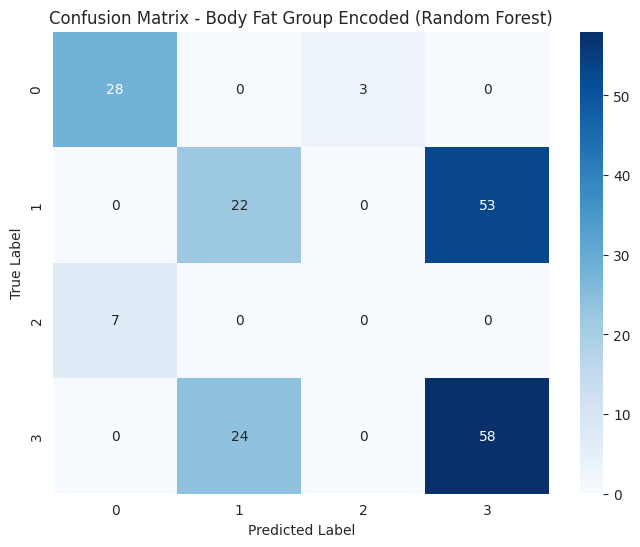

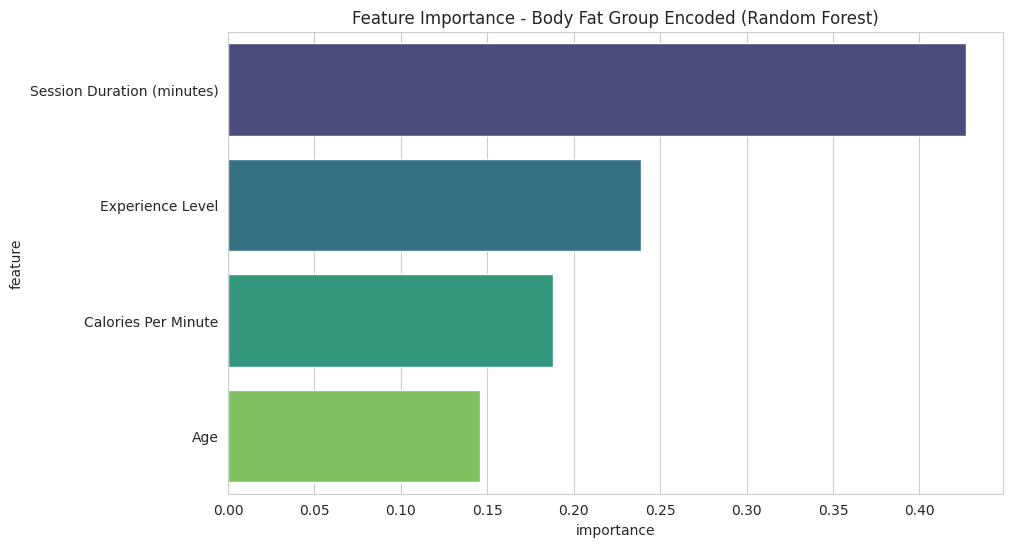

RF Experience Level CV Accuracy: 0.7829 ± 0.0288

Experience Level Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.57      0.71        75
           1       0.71      0.96      0.82        82
           2       1.00      1.00      1.00        38

    accuracy                           0.82       195
   macro avg       0.88      0.85      0.84       195
weighted avg       0.85      0.82      0.81       195



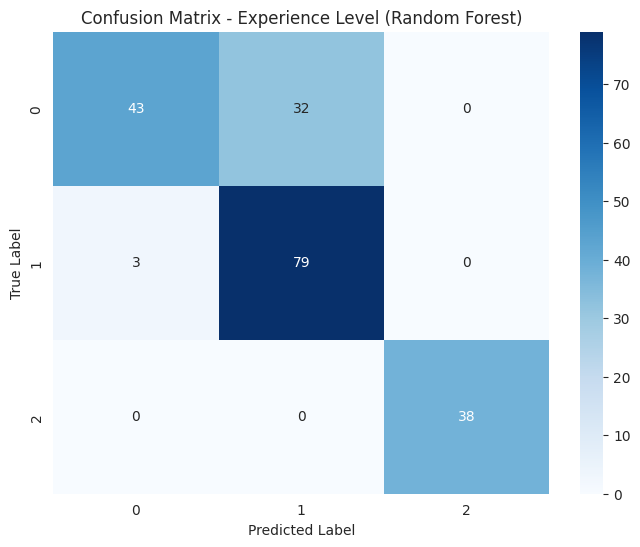

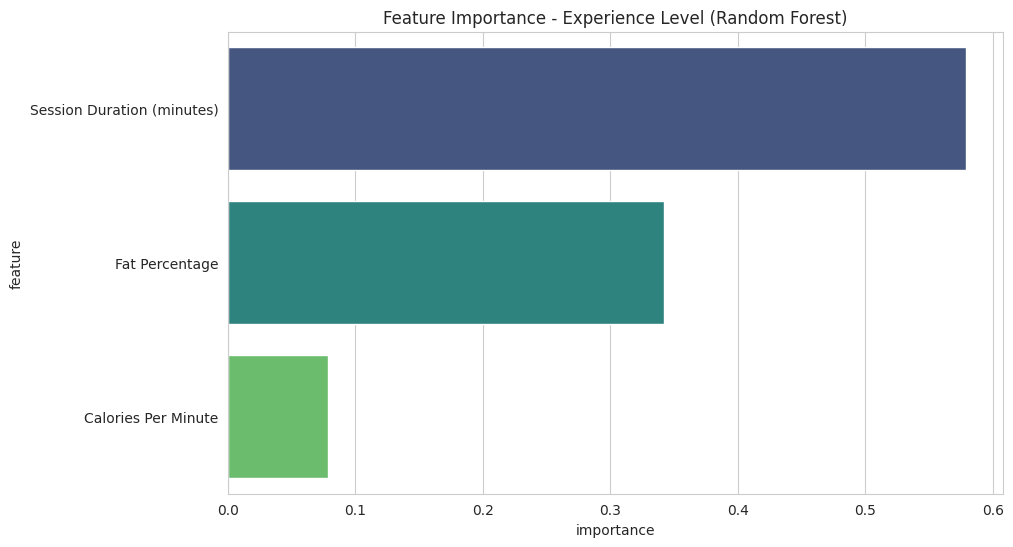

RF Age Group Encoded CV Accuracy: 0.6568 ± 0.0233

Age Group Encoded Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.83      0.72       118
           1       0.49      0.25      0.33        77

    accuracy                           0.60       195
   macro avg       0.56      0.54      0.52       195
weighted avg       0.57      0.60      0.56       195



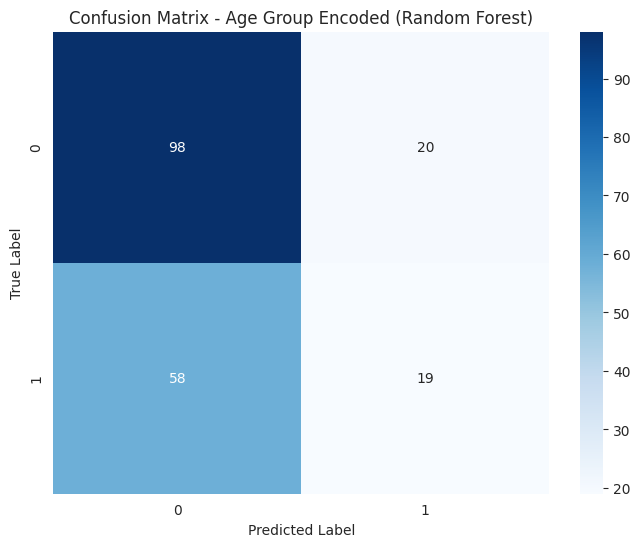

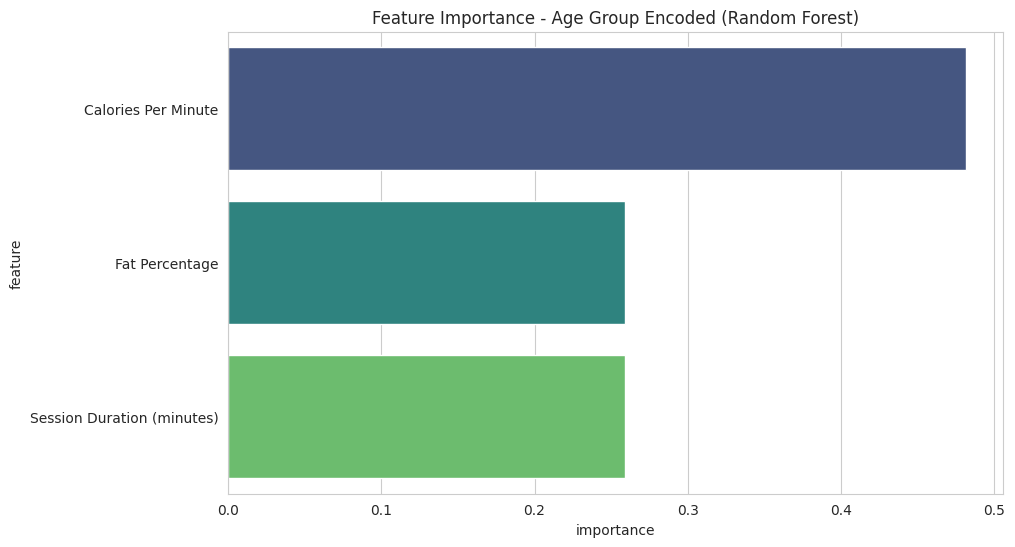

In [10]:
# 1. Random Forest Model
rf_result = run_random_forest(df, rf_top_features_dict)

# 2. XGBoost Model
xgb_result = run_xgboost(df, xgb_top_features_dict)

# 3. kNN
knn_result = run_knn(df, xgb_top_features_dict)

# 4. Select model, features with highest accuracy
best_features_models = select_models_features(df, rf_result, xgb_result, knn_result)
print_models(best_features_models)

### Top Feature Identification
- **XGBoost** outperformed both Random Forest and k-Nearest Neighbor models for every target prior to hyperparameter tuning.
- **Body Fat Group** was predicted with 0.6233 accuracy using identified top features **Gender**, **Session Duration**, and **Experience Level**.
- **Experience Level** saw 0.7918 accuracy with **Session Duration** and **Fat Percentage**.
- **Age Group** had 0.6812 accuracy utilizing features **Gender**, **CPM**, **Body Fat Group**, and **Experience Level** features.

## 9. Modeling and Final Evaluation

Fitting 10 folds for each of 54 candidates, totalling 540 fits

Best parameters for Body Fat Group Encoded: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV Accuracy: 0.6331
Fitting 10 folds for each of 54 candidates, totalling 540 fits

Best parameters for Experience Level: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Accuracy: 0.8037
Fitting 10 folds for each of 54 candidates, totalling 540 fits

Best parameters for Age Group Encoded: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV Accuracy: 0.7040

Final Evaluation - Body Fat Group Encoded
              precision    recall  f1-score   support

           0       0.83      0.97      0.90        31
           1       0.58      0.51      0.54        75
           2       0.50      0.14      0.22         7
           3       0.59      0.66      0.62        82

    accuracy                           0.63       195
   macr

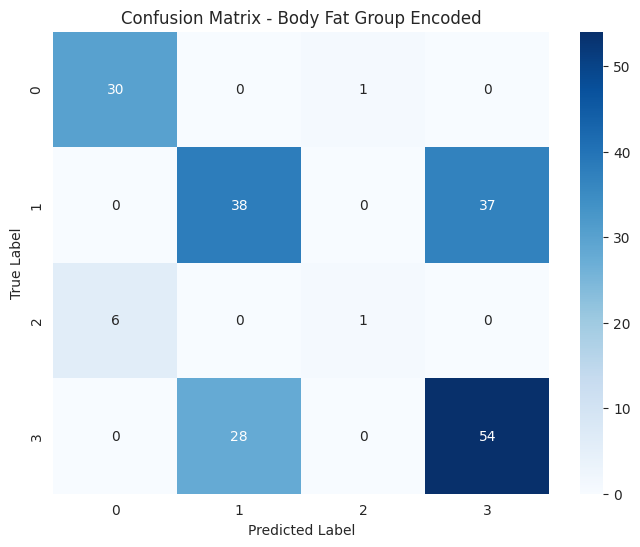


Final Evaluation - Experience Level
              precision    recall  f1-score   support

           0       1.00      0.57      0.73        75
           1       0.72      1.00      0.84        82
           2       1.00      1.00      1.00        38

    accuracy                           0.84       195
   macro avg       0.91      0.86      0.86       195
weighted avg       0.88      0.84      0.83       195



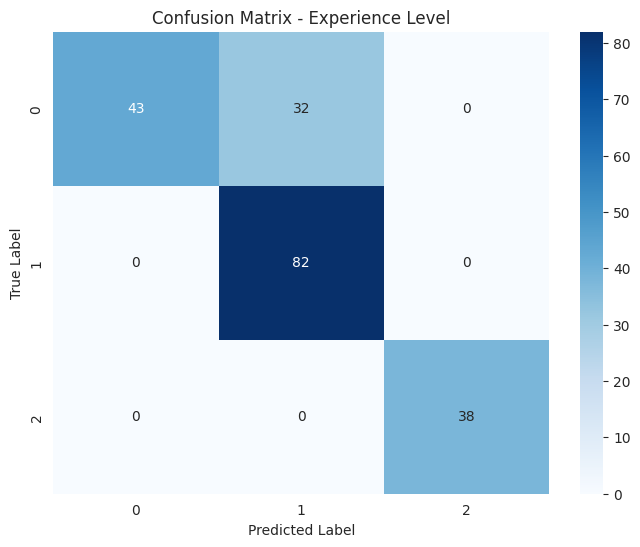


Final Evaluation - Age Group Encoded
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       118
           1       0.65      0.52      0.58        77

    accuracy                           0.70       195
   macro avg       0.68      0.67      0.67       195
weighted avg       0.69      0.70      0.69       195



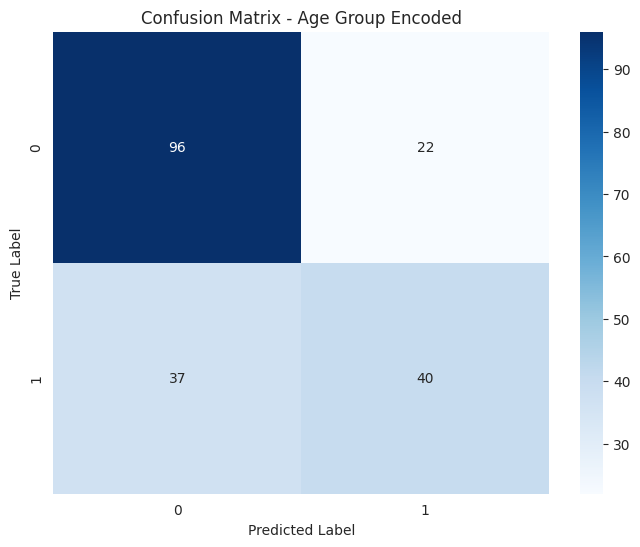

{'Body Fat Group Encoded': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device='cuda', early_stopping_rounds=None,
               enable_categorical=True, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.01, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, ...),
 'Experience Level': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, d

In [14]:
## Modeling & Final Evaluation
results_dict = tune_and_evaluate(df, best_features_models)
final_evaluation(df, results_dict)

## Modeling Results

After extensive feature selection and hyperparameter tuning, the following models were developed:

### Final Model Performance

| Target                  | Best Model | CV Accuracy | Final Test Accuracy |
|-------------------------|------------|-------------|---------------------|
| **Experience Level**    | XGBoost    | 0.80        | **0.84**            |
| **Age Group**           | XGBoost    | 0.70        | **0.70**            |
| **Body Fat Group**      | XGBoost    | 0.63        | **0.63**            |

**Note:** Predicting Workout Type Preference yielded low accuracy (~0.30) and was excluded from final models due to insufficient signal.

### Conclusions & Key Learnings
- **Strength Training** and **Cardio** are the most popular workout types across genders.
- Adult males showed a relatively higher preference for Yoga (likely influenced by selection bias in the dataset).\
- Predictive modeling performed best for Experience Level (0.84 accuracy), demonstrating that fitness experience can be reasonably predicted from intensity and demographic features.

**Practical Value:** These insights support age-based intensity recommendations in fitness apps and programs, while highlighting the challenges of predicting specific workout preferences.

**Future Work:** Incorporate additional features such as fitness goals, motivation, or injury history to improve prediction accuracy.